# Counting plants: imperfect and heterogeneous detection — GLMM reproduction (Figure 2)

**Paper:** Perret, J., Besnard, A., Charpentier, A., & Papuga, G. (2023).
*Plants stand still but hide: Imperfect and heterogeneous detection is the rule when counting plants.*
Journal of Ecology. DOI: [10.1111/1365-2745.14110](https://doi.org/10.1111/1365-2745.14110)

**Author code & data:** [JanPerret/Individual_detection_in_plant_counts](https://github.com/JanPerret/Individual_detection_in_plant_counts), pinned commit `304f6cc7eb5cbdfc79e13068ed8d509f6058a257`
(Code: GPL-3.0. Data: CC BY-NC-ND 4.0.)

## Purpose and exact scope

This notebook statistically reproduces the paper's **final binomial GLMM of individual
detection probability** (`mod_final_s`, the standardized-predictor version) and its
**Figure 2** — the log-odds coefficient estimates with 95% confidence intervals — by running
the **authors' own R code** (verbatim excerpts from
`detection_in_plant_counts_Analysis_and_Figures.R`) on the authors' published tidy dataset
`data/tidy/df_3_methods_3_without_excess_detections.csv` (~4,319 observer counts; 3 counting
methods × 300 quadrats × many observers).

**This is a partial demonstration.** Not reproduced: the raw-data pipeline (PCA habitat-closure
composite — already pre-computed in the tidy CSV), Figures 1/3/4, DHARMa residuals checks,
false-positive analysis, and the AIC model-selection search (the published script fits the
already-selected final model; it does not re-run the selection).

**Execution status:** executed on a Google Colab **CPU** runtime (no GPU is used anywhere:
this is a classical mixed-model fit in R).

## 英概要（日本語）
本ノートブックは、Perret et al. 2023 (J. Ecology) の「植物個体の検出確率」二項 GLMM
（標準化予測子版 `mod_final_s`）を、著者自身の R コード（`detection_in_plant_counts_Analysis_and_Figures.R`
の逐語引用、commit `304f6cc7eb5c`）をそのまま Colab の R (`Rscript`) で実行し、
**Figure 2（ログオッズ回帰係数と95%信頼区間のプロット）**を再現するものです。
生データの前処理パイプライン・Figure 1/3/4・DHARMa 診断・AIC モデル選択は対象外の部分再現です。
GPU は不要で CPU ランタイムで動作します。Python のセルは R スクリプトの起動（オーケストレーション）だけを行います。

> **Note on language / 使用ツールについて:** The authors' implementation is in **R** (GPL-3.0).
> The scientific code below is **copied verbatim from the authors' pinned script**; the Python
> cells only download inputs and invoke `Rscript` (AI-assisted orchestration, not a translation).
> 本ノートブックの科学計算は著者の R コードの逐語引用です。Python は起動補助のみです。

## Runtime selection / ランタイムの選択

**Use a standard CPU runtime** (Runtime → Change runtime type → CPU). No GPU/TPU is needed:
`lme4::glmer` is a classical optimizer, not a neural network. Expected total time on Colab CPU:
**~5–15 minutes** (≈2–5 min apt package install + downloads, ≈1–5 min model fit; measured values
are printed below by the cells themselves). Downloads: one ~418 KB CSV + ~35 MB of prebuilt R
packages.

**Run all** (Runtime → Run all) from a fresh runtime; every step is self-contained under `/content`.
制限：無料枠では利用可能時間や速度が異なる場合があります。GPU は不要です。

### Check R availability
The standard Colab runtime ships R. This cell verifies `Rscript` and prints the R version
before anything is installed.
**Expected result:** an `R version 4.x.x` string. / Colab 標準ランタイムに同梱の R を確認します。

In [ ]:
import subprocess
r = subprocess.run(["Rscript", "-e", "cat(R.version.string)"],
                   capture_output=True, text=True, timeout=300)
print(r.stdout.strip())
assert r.returncode == 0, r.stderr

R version 4.6.1 (2026-06-24)


### Install the R packages used by the minimal analysis path
The author's script loads ten R libraries, but the Figure 2 path needs only:
`lme4` (binomial GLMM), `broom.mixed` (tidy coefficient table), `readr` (`read_csv2`),
`ggplot2` (Figure 2), plus `dplyr`/`tibble` used by the excerpt. Colab's R is built on the
[r2u](https://cran.r-project.org/bin/linux/ubuntu/) CRAN-from-apt repository, so all of these
install as **prebuilt binaries** (`r-cran-*`) — no source compilation.
**Expected result:** apt reports the packages already or newly installed (exit code 0).
/ 最小経路に必要な R パッケージのみをビルドなしでインストールします。

In [ ]:
%%bash
set -o pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq \
  r-cran-lme4 r-cran-broom.mixed r-cran-readr r-cran-ggplot2 r-cran-dplyr r-cran-tibble
echo "APT_EXIT=$?"
Rscript -e 'suppressMessages({library(lme4);library(readr);library(ggplot2)});
  cat("lme4", as.character(packageVersion("lme4")),
      "| broom.mixed", as.character(packageVersion("broom.mixed")),
      "| readr", as.character(packageVersion("readr")), "\n")'

Selecting previously unselected package r-cran-coda.
(Reading database ... 122815 files and directories currently installed.)
Preparing to unpack .../00-r-cran-coda_0.19-4.1-1.ca2404.1_all.deb ...
Unpacking r-cran-coda (0.19-4.1-1.ca2404.1) ...
Selecting previously unselected package r-cran-globals.
Preparing to unpack .../01-r-cran-globals_0.19.1-1.ca2404.1_all.deb ...
Unpacking r-cran-globals (0.19.1-1.ca2404.1) ...
Selecting previously unselected package r-cran-listenv.
Preparing to unpack .../02-r-cran-listenv_1.1.0-1.ca2404.1_all.deb ...
Unpacking r-cran-listenv (1.1.0-1.ca2404.1) ...
Selecting previously unselected package r-cran-parallelly.
Preparing to unpack .../03-r-cran-parallelly_1.48.0-1.ca2404.1_amd64.deb ...
Unpacking r-cran-parallelly (1.48.0-1.ca2404.1) ...
Selecting previously unselected package r-cran-future.
Preparing to unpack .../04-r-cran-future_1.76.0-1.ca2404.1_all.deb ...
Unpacking r-cran-future (1.76.0-1.ca2404.1) ...
Selecting previously unselected package r

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


### Download the authors' tidy dataset (pinned commit, verified by Git blob hash)
Dataset bytes may only be downloaded here on the Colab VM. We fetch the exact file
`data/tidy/df_3_methods_3_without_excess_detections.csv` from the pinned commit `304f6cc7eb5cbdfc79e13068ed8d509f6058a257` and verify it two ways:
expected size (417,569 bytes, from the repository tree metadata) and the **Git blob SHA-1**
`74bea443b8f2a2a01b8463fe14db3ade8f0401d4` (the hash GitHub's tree API reports for this file).
**Expected result:** `VERIFIED 74bea443... 417569`.
/ 著者の整然データ CSV をピン留めたコミットからダウンロードし、サイズと Git blob SHA-1 で検証します。

In [ ]:
import hashlib
from pathlib import Path
import urllib.request

URL = "https://raw.githubusercontent.com/JanPerret/Individual_detection_in_plant_counts/304f6cc7eb5cbdfc79e13068ed8d509f6058a257/data/tidy/df_3_methods_3_without_excess_detections.csv"
dest = Path("/content/data/tidy"); dest.mkdir(parents=True, exist_ok=True)
csv_path = dest / "df_3_methods_3_without_excess_detections.csv"
urllib.request.urlretrieve(URL, csv_path)  # pinned raw URL, no token needed

data = csv_path.read_bytes()
assert not data.startswith(b"\x3c"), "HTML error page downloaded"  # '<'
expected_size = 417569
assert len(data) == expected_size, (len(data), expected_size)
blob_sha1 = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
expected_sha = "74bea443b8f2a2a01b8463fe14db3ade8f0401d4"
assert blob_sha1 == expected_sha, blob_sha1
print(f"VERIFIED {blob_sha1} {len(data)} bytes")

VERIFIED 74bea443b8f2a2a01b8463fe14db3ade8f0401d4 417569 bytes


### Input preview: what the model is fit to
Before fitting anything we look at the actual observations: dimensions, columns, and a small
graph of **observed detection probability per counting method** (30-second estimate, unlimited
count, cell count). The paper reports mean detection of ≈0.44 (quick), 0.59 (unlimited) and 0.74
(cell) per field session, so the observed per-count means should be in the same ranges.
This graph is an **additional visualization created for this notebook**, not an author figure.
/ 入力データ（検出確率 `prop_detect`、真の個体数 `count_TRUE` など）の構成と、計数方法ごとの
検出確率を確認します。これは本ノートブック独自の追加可視化です。

shape: (4319, 14)
columns: ['species', 'obs_id', 'obs_letter', 'counting_method', 'quadrat_num', 'count', 'counting_time', 'prop_detect', 'quadrat_order', 'count_TRUE', 'species_conspicuousness', 'habitat_closure', 'exp_bota', 'excess_detect']


,species,obs_id,obs_letter,counting_method,quadrat_num,count,counting_time,prop_detect,quadrat_order,count_TRUE,species_conspicuousness,habitat_closure,exp_bota,excess_detect
0,ALLCHA,obs_autm,A,count_30s,quadrat1,4,30,0.500000,1,8,1,-0.209042,2,0
1,ALLCHA,obs_autm,A,count_30s,quadrat10,3,30,0.375000,10,8,1,-0.377625,2,0
2,ALLCHA,obs_autm,A,count_30s,quadrat2,2,30,0.666667,2,3,1,0.129232,2,0


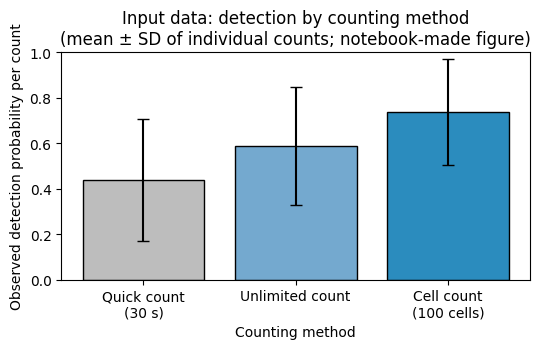

       prop_detect  count_TRUE  counting_time  exp_bota  \
count     4319.000    4319.000       4319.000  4319.000   
mean         0.586      57.114        206.476     2.447   
std          0.281      59.834        282.170     1.345   
min          0.000       1.000          0.000     1.000   
25%          0.368      16.000         30.000     1.000   
50%          0.611      38.000         80.000     2.000   
75%          0.820      76.000        275.000     3.000   
max          1.000     295.000       2392.000     5.000   

       species_conspicuousness  habitat_closure  
count                 4319.000         4319.000  
mean                     2.079           -0.015  
std                      1.021            1.289  
min                      1.000           -1.944  
25%                      1.000           -1.229  
50%                      2.000            0.099  
75%                      3.000            0.770  
max                      4.000            3.452  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(csv_path, sep=";", decimal=",")
print("shape:", df.shape)
print("columns:", list(df.columns))
display(df.head(3))

order = ["count_30s", "count_1m", "count_cells"]
labels = ["Quick count\n(30 s)", "Unlimited count", "Cell count\n(100 cells)"]
means = df.groupby("counting_method")["prop_detect"].mean().reindex(order)
sds = df.groupby("counting_method")["prop_detect"].std().reindex(order)

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.bar(labels, means, yerr=sds, capsize=4, color=["#bdbdbd", "#74a9cf", "#2b8cbe"], edgecolor="black")
ax.set_ylabel("Observed detection probability per count")
ax.set_xlabel("Counting method")
ax.set_ylim(0, 1)
ax.set_title("Input data: detection by counting method\n(mean ± SD of individual counts; notebook-made figure)")
fig.tight_layout()
fig.savefig("/content/input_detection_by_method.png", dpi=150)
plt.show()
print(df[["prop_detect", "count_TRUE", "counting_time", "exp_bota",
          "species_conspicuousness", "habitat_closure"]].describe().round(3))

### R step 1 — author's data preparation (verbatim, lines 458–477)
This cell writes the author's data-preparation excerpt to `/content/work/step1_data.R` and runs
it with `Rscript`. Verbatim operations: `read_csv2` of the tidy CSV; counting time from seconds
to minutes; manual interaction coding (`counting_time_1m`, `counting_time_cells`, so the
30-second method gets no time slope); `count_30s` as factor reference level; a unique
`quadrat_id`. **Only the file path is adapted** (`./data/tidy/…` → `/content/data/tidy/…`).
**Expected result:** dims ≈ `4319 17` (14 columns + 3 derived).
/ 著者のデータ前処理コード（逐語）を `/content` に書き出し `Rscript` で実行します。

In [ ]:
from pathlib import Path
import subprocess, textwrap

step1 = r'''# ---- Verbatim excerpt: JanPerret/Individual_detection_in_plant_counts @ 304f6cc7eb5cbdfc79e13068ed8d509f6058a257
# ---- detection_in_plant_counts_Analysis_and_Figures.R lines 458-477
# ---- (only file paths adapted for the Colab VM; no other changes.
# ---- The author's script loads tidyverse; its tibble() call needs the tibble package.)
library(readr)
library(tibble)

df_3_methods <- read_csv2(file = "/content/data/tidy/df_3_methods_3_without_excess_detections.csv")

# convert counting time from seconds to minutes
df_3_methods$counting_time <- df_3_methods$counting_time/60

# add columns to code manually the interaction counting_time * counting_method without estimating a slope for count_30s
counting_time_1m <- df_3_methods$counting_time
counting_time_1m[which(df_3_methods$counting_method == "count_30s" | df_3_methods$counting_method == "count_cells")] <- 0
counting_time_cells <- df_3_methods$counting_time
counting_time_cells[which(df_3_methods$counting_method == "count_30s" | df_3_methods$counting_method == "count_1m")] <- 0
df_3_methods <- cbind(df_3_methods, counting_time_1m, counting_time_cells)

# set the counting method count_30s as reference level
df_3_methods$counting_method <- factor(df_3_methods$counting_method, levels = c("count_30s", "count_1m", "count_cells"))

# add a column with a unique quadrat identification
df_3_methods <- cbind(df_3_methods, quadrat_id = paste0(df_3_methods$species, "_", df_3_methods$quadrat_num))

# convert to tibble
df_3_methods <- tibble(df_3_methods)

cat("dims:", dim(df_3_methods)[1], "rows x", dim(df_3_methods)[2], "cols\n")
dir.create("/content/work", showWarnings = FALSE)
saveRDS(df_3_methods, "/content/work/df_3_methods.rds")
'''

Path("/content/work").mkdir(parents=True, exist_ok=True)
Path("/content/work/step1_data.R").write_text(step1)
res = subprocess.run(["Rscript", "/content/work/step1_data.R"],
                     capture_output=True, text=True, timeout=1800)
print(res.stdout)
if res.returncode != 0:
    raise RuntimeError(res.stderr)

dims: 4319 rows x 17 cols



### R step 2 — fit the paper's final GLMM `mod_final_s` (verbatim, lines 497–508)
The paper's detection model: a binomial GLMM with logit link, response `prop_detect`
(detected / true count), **weights = `count_TRUE`** (number of trials), random intercepts for
`species`, `species:quadrat_id` (quadrat nested in species) and `obs_id` (observer), and all
fixed effects/interactions selected by the authors' AIC procedure: species conspicuousness ×
habitat closure × counting method, botany experience, density (`count_TRUE`), quadrat order,
and the extra counting-time interactions. Continuous predictors are `scale()`d; coefficients are
therefore standardized log-odds betas, as plotted in Figure 2.
**Expected result:** a converged fit summary over ~4,319 counts (warnings such as
`boundary (singular) fit` would be printed if they occurred).
/ 論文の最終 GLMM `mod_final_s`（逐語）をあてはめます。二項 GLMM・logit リンク・
重み `count_TRUE`・標準化連続予測子です。

In [ ]:
from pathlib import Path
import subprocess

step2 = r'''# ---- Verbatim excerpt: lines 497-508 of the author's analysis script (mod_final_s)
library(lme4)
df_3_methods <- readRDS("/content/work/df_3_methods.rds")

mod_final_s <- glmer(prop_detect ~ (1|species) + (1|species:quadrat_id) + (1|obs_id)
                     + scale(species_conspicuousness) * habitat_closure
                     + scale(species_conspicuousness) * counting_method
                     + habitat_closure * counting_method
                     + scale(exp_bota) * counting_method
                     + scale(count_TRUE) * counting_method
                     + scale(quadrat_order) * counting_method
                     + scale(counting_time_1m) * habitat_closure
                     + scale(counting_time_1m) * scale(species_conspicuousness)
                     + scale(counting_time_cells) * scale(species_conspicuousness)
                     + scale(counting_time_cells) * habitat_closure,
                     family = binomial, data = df_3_methods, weight = count_TRUE)

print(summary(mod_final_s))
saveRDS(mod_final_s, "/content/work/mod_final_s.rds")
'''

Path("/content/work/step2_model.R").write_text(step2)
res = subprocess.run(["Rscript", "/content/work/step2_model.R"],
                     capture_output=True, text=True, timeout=3600)
print(res.stdout)
if res.stderr.strip():
    print("R stderr/warnings:", res.stderr)
if res.returncode != 0:
    raise RuntimeError(res.stderr)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: prop_detect ~ (1 | species) + (1 | species:quadrat_id) + (1 |  
    obs_id) + scale(species_conspicuousness) * habitat_closure +  
    scale(species_conspicuousness) * counting_method + habitat_closure *  
    counting_method + scale(exp_bota) * counting_method + scale(count_TRUE) *  
    counting_method + scale(quadrat_order) * counting_method +  
    scale(counting_time_1m) * habitat_closure + scale(counting_time_1m) *  
    scale(species_conspicuousness) + scale(counting_time_cells) *  
    scale(species_conspicuousness) + scale(counting_time_cells) *  
    habitat_closure
   Data: df_3_methods
Weights: count_TRUE

      AIC       BIC    logLik -2*log(L)  df.resid 
  28735.4   28913.7  -14339.7   28679.4      4291 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-18.0220  -0.8900   0.0632   0.9015  13.3415 

Random effects:
 Groups    

### R step 3 — extract Figure 2 betas and render the figure
Author's Figure 2 pipeline (lines 516–588, near-verbatim): `broom.mixed::tidy()` on the
standardized model with 95% confidence intervals; term names cleaned (`scale(`, `:`, `_` …);
fixed and random effects split; a sign/p-value color code (`positive` / `negative` / `NS`);
log-odds dot-and-errorbar plot saved to `/content/output/Figure2_model_betas.png` (author's
600 dpi / 9.5×7 in settings) and both coefficient tables to CSV.

**One documented, minimal adaptation:** the author's script selects the three random-effect
rows with hard-coded indices `c(26, 27, 28)`, which is fragile across lme4/broom.mixed
versions. We select rows by the `effect` column (`ran_pars` → `random`) and fix the
`species:quadrat_id` label by name instead of by position. The resulting tables and figure are
identical in content.
/ 図2の係数表（標準化ベータ・95%CI）を `broom.mixed::tidy` で取り出し、著者の設定のまま
Figure 2 を PNG に保存します。ランダム効果行の選択のみ、バージョンに脆いインデックス指定を
名前指定に置き換えています（出力内容は同一）。

In [ ]:
from pathlib import Path
import subprocess

step3 = r'''# ---- Verbatim excerpt: lines 516-588 of the author's analysis script (Figure 2)
# ---- Adaptation (documented in the markdown cell above): random-effect rows are
# ---- selected by the effect/group columns, not by hard-coded row indices.
library(broom.mixed)
library(ggplot2)

mod_final_s <- readRDS("/content/work/mod_final_s.rds")

# make the table with the betas
df_mod_final_s_betas <- broom.mixed::tidy(mod_final_s, conf.int = TRUE, effects = c("fixed", "ran_pars"))

# mark the random-effect rows (adaptation of author's c(26,27,28) index selection)
df_mod_final_s_betas$effect[df_mod_final_s_betas$effect == "ran_pars"] <- "random"

# move the columns with the confidence interval to the left
df_mod_final_s_betas <- subset(df_mod_final_s_betas, select = c(effect:std.error, conf.low, conf.high, statistic, p.value))

# change presentation of random effects
rand_idx <- which(df_mod_final_s_betas$effect == "random")
df_mod_final_s_betas$term[rand_idx] <- df_mod_final_s_betas$group[rand_idx]
df_mod_final_s_betas <- subset(df_mod_final_s_betas, select = -group)

# clean the variable names
df_mod_final_s_betas$term <- gsub(pattern = "scale(", replacement = "", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = ")", replacement = "", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "(", replacement = "", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = ":", replacement = " x ", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "count_1m", replacement = " [unlimited count]", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "count_cells", replacement = " [cell count]", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "count_TRUE", replacement = "Density", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "exp_bota", replacement = "Botany experience", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "counting_time_1m", replacement = "Counting_time x counting_method [unlimited count]", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "counting_time_cells", replacement = "Counting_time x counting_method [cell count]", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "counting_method", replacement = "Method", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "_", replacement = " ", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "species conspicuousness", replacement = "Species conspicuousness", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "habitat closure", replacement = "Habitat closure", x = df_mod_final_s_betas$term, fixed = TRUE)
df_mod_final_s_betas$term <- gsub(pattern = "quadrat order", replacement = "Quadrat order", x = df_mod_final_s_betas$term, fixed = TRUE)

# make two separate tables for the fixed and the random effects
df_mod_final_s_betas_random_effects <- subset(df_mod_final_s_betas, df_mod_final_s_betas$effect == "random")
df_mod_final_s_betas_random_effects <- subset(df_mod_final_s_betas_random_effects, select = -effect)

df_mod_final_s_betas <- subset(df_mod_final_s_betas, df_mod_final_s_betas$effect == "fixed")
df_mod_final_s_betas <- subset(df_mod_final_s_betas, select = -effect)

# remove empty columns and show both the variance and the SD of the random effects
df_mod_final_s_betas_random_effects <- df_mod_final_s_betas_random_effects[, c(1:3)]
colnames(df_mod_final_s_betas_random_effects) <- c("term", "SD", "variance")
df_mod_final_s_betas_random_effects$variance <- df_mod_final_s_betas_random_effects$SD^2
# adaptation: restore the species:quadrat_id label by name (author did this positionally)
df_mod_final_s_betas_random_effects$term[df_mod_final_s_betas_random_effects$term == "species x quadrat id"] <- "species:quadrat_id"

# make the table for the plot
df_mod_betas_plot <- cbind(df_mod_final_s_betas, signif = NA)

# fill column signif for the color of points and confidence intervals
for (i in 1:nrow(df_mod_betas_plot)) {
  if (df_mod_betas_plot$estimate[i] > 0) {df_mod_betas_plot$signif[i] <- "positive"}
  if (df_mod_betas_plot$estimate[i] < 0) {df_mod_betas_plot$signif[i] <- "negative"}
  if (df_mod_betas_plot$p.value[i] > 0.05) {df_mod_betas_plot$signif[i] <- "NS"}
}

# make term an ordered factor
df_mod_betas_plot$term <- factor(df_mod_betas_plot$term, levels = rev(df_mod_betas_plot$term))

# make the plot
plot_figure_2 <- ggplot(df_mod_betas_plot, aes(x = estimate, y = term, color = signif)) +
  geom_vline(xintercept = 0, color = "black") +
  geom_point(size = 2.3) +
  geom_errorbar(aes(xmin = conf.low, xmax = conf.high), width = 0, size = 0.8) +
  theme_bw() +
  scale_color_manual(values = c("#e31a1c", "#525252", "#3690c0")) +
  theme(legend.position = "none") +
  xlab("Log-Odds") +
  ylab("")

# save the plot and the coefficient tables (author saved ./output/Figure2_model_betas.pdf/.png)
dir.create("/content/output", showWarnings = FALSE)
png(file = "/content/output/Figure2_model_betas.png", width = 9.5, height = 7, units = "in", res = 600)
print(plot_figure_2)
dev.off()

write.csv(df_mod_final_s_betas, file = "/content/output/figure2_betas_fixed.csv", row.names = FALSE)
write.csv(df_mod_final_s_betas_random_effects, file = "/content/output/figure2_betas_random.csv", row.names = FALSE)

cat("---- Fixed effects (standardized log-odds betas) ----\n")
print(as.data.frame(df_mod_final_s_betas[, c("term", "estimate", "std.error", "conf.low", "conf.high", "p.value")]), digits = 3)
cat("\n---- Random effects (SD; variance) ----\n")
print(df_mod_final_s_betas_random_effects, digits = 3)
'''

Path("/content/work/step3_fig2.R").write_text(step3)
res = subprocess.run(["Rscript", "/content/work/step3_fig2.R"],
                     capture_output=True, text=True, timeout=3600)
print(res.stdout)
if res.stderr.strip():
    print("R stderr/warnings:", res.stderr)
if res.returncode != 0:
    raise RuntimeError(res.stderr)

null device 
          1 
---- Fixed effects (standardized log-odds betas) ----
                                                                 term estimate
1                                                           Intercept -0.00446
2                                             Species conspicuousness  0.21039
3                                                     Habitat closure -0.31016
4                                            Method [unlimited count]  0.42564
5                                                 Method [cell count]  0.84359
6                                                   Botany experience  0.05947
7                                                             Density -0.29064
8                                                       Quadrat order  0.01267
9                            Counting time x Method [unlimited count]  0.20875
10                                Counting time x Method [cell count]  0.47902
11                          Species conspicuousness

### Figure 2 — reproduced coefficient plot
The saved 600 dpi PNG produced by the author's own plotting code is displayed here, followed by
the coefficient table as an inspectable data frame. A CSV export (`figure2_betas_fixed.csv`,
`figure2_betas_random.csv`) is written next to it inside the Colab VM under `/content/output/`.
/ 著者のプロットコードが保存した Figure 2 の PNG と係数表を表示します（CSV も
`/content/output/` に書き出されます）。

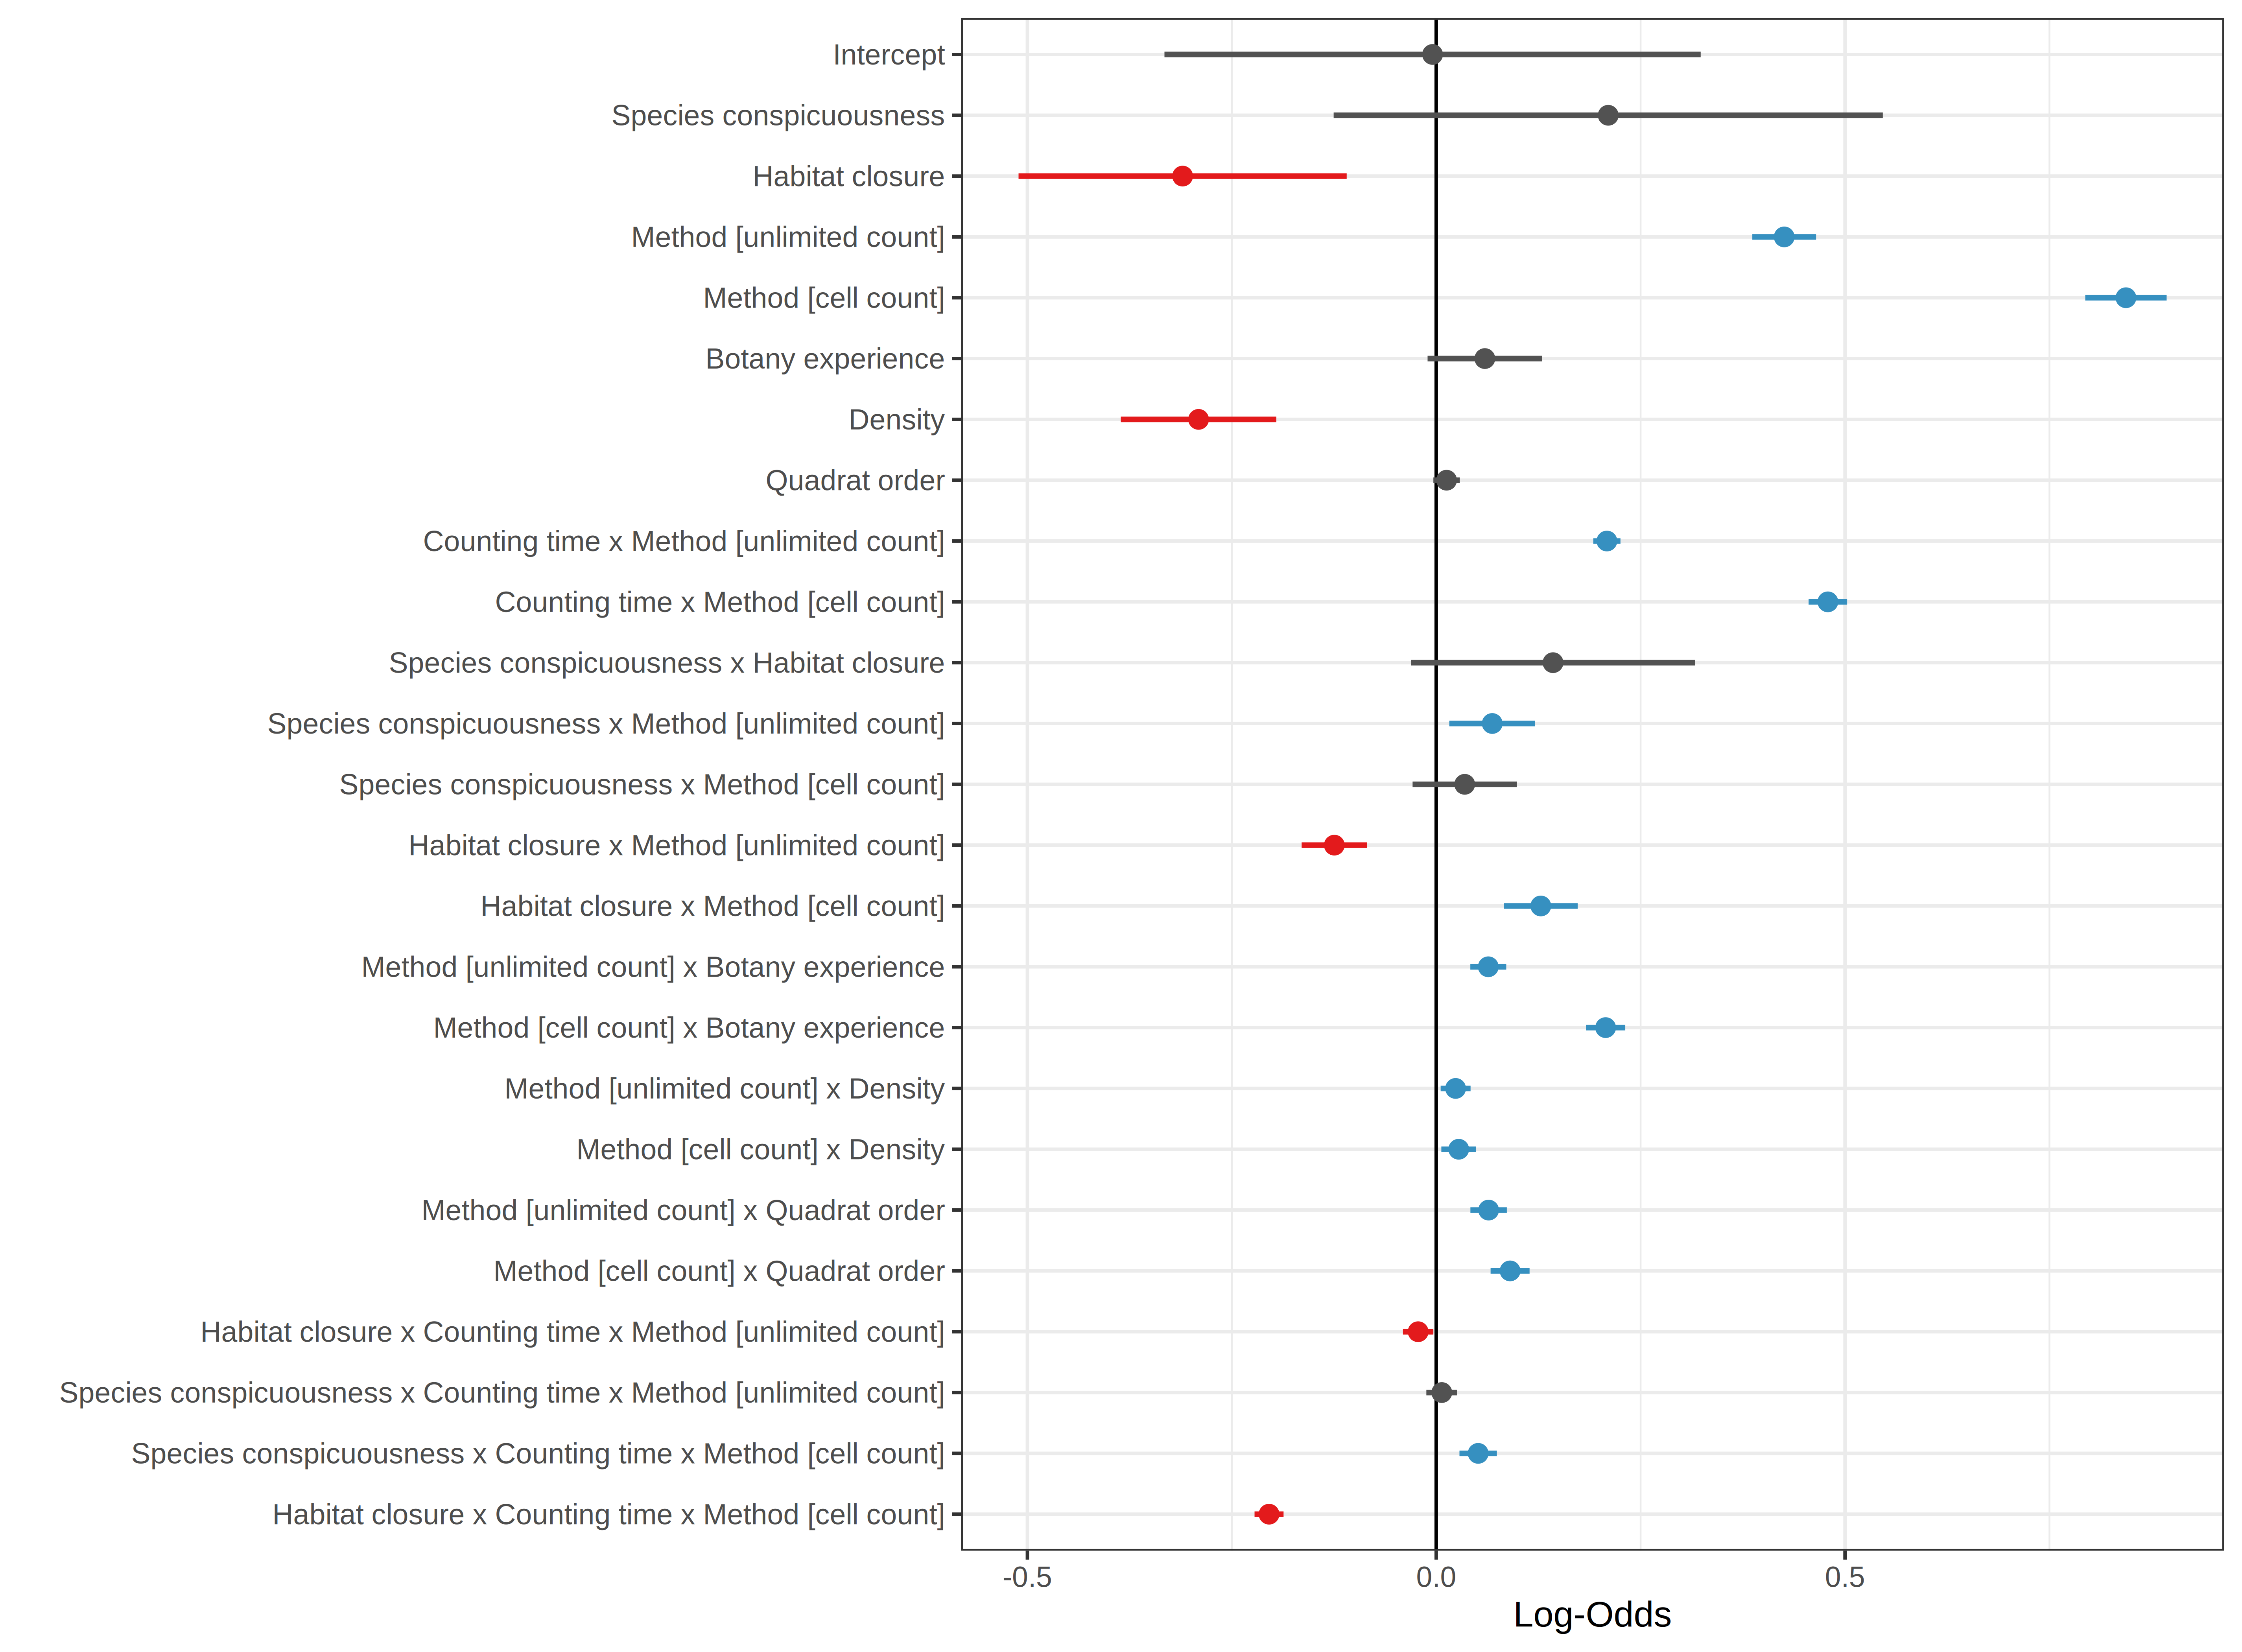

,term,estimate,conf.low,conf.high,p.value
0,Intercept,-0.004,-0.332,0.323,0.979
1,Species conspicuousness,0.210,-0.125,0.546,0.219
2,Habitat closure,-0.310,-0.511,-0.110,0.002
3,Method [unlimited count],0.426,0.387,0.465,0.000
4,Method [cell count],0.844,0.794,0.893,0.000
5,Botany experience,0.059,-0.011,0.130,0.096
6,Density,-0.291,-0.386,-0.196,0.000
7,Quadrat order,0.013,-0.003,0.029,0.124
8,Counting time x Method [unlimited count],0.209,0.192,0.225,0.000
9,Counting time x Method [cell count],0.479,0.455,0.503,0.000


,term,SD,variance
0,species:quadrat_id,0.647,0.419
1,obs id,0.399,0.159
2,species,0.765,0.585


In [ ]:
from IPython.display import Image, display
import pandas as pd

display(Image(filename="/content/output/Figure2_model_betas.png", width=820))
betas = pd.read_csv("/content/output/figure2_betas_fixed.csv")
display(betas[["term", "estimate", "conf.low", "conf.high", "p.value"]].round(3))
rand = pd.read_csv("/content/output/figure2_betas_random.csv")
display(rand.round(3))

### Interpretation and comparison with the paper
**What was executed:** the authors' own R code (pinned commit, verbatim excerpts) fitting their
final standardized binomial GLMM on their published tidy dataset, and their own Figure 2
rendering code. The figure above is the reproduction output, on the same log-odds scale as the
published Figure 2.

**How to read it against the paper's claims** (paper Results / study flow, bioRxiv v1 wording):
detection should (i) be far below 1 on average for all methods; (ii) **increase** with species
conspicuousness; (iii) **decrease** with habitat closure and with density (`count_TRUE`);
(iv) **increase** from quick → unlimited → cell count, with the counting-time slopes
(`Counting_time x method …`) positive where effort helps; (v) rise with botany experience
(quick count), i.e. experience × quick-count interaction negative relative to the other methods.
Random-effect SDs quantify residual heterogeneity between species/quadrats and observers — the
paper's headline message that *no observer detected all individuals and detection is
heterogeneous*.

**Scope limits / 注意:** This validates the paper's published statistical analysis and Figure 2
on the published dataset — it does not re-derive the raw-data pipeline, does not re-run the AIC
selection, and does not verify the published dataset-level claims beyond this model. If the
journal (J Ecol 2023) wording or numbers differ from the bioRxiv v1 preprint, the repository
code is the authoritative reproduction target here (its README cites the J Ecol DOI). The
study-flow variance-component quotes (σ ≈ 0.58 / 0.42 / 0.16) come from the preprint text and
use different random-effect naming (session / quadrat / observer) than the final model's
(species / species:quadrat_id / observer); compare the printed SDs with that caveat.
/ 実行したのは著者コードそのものによる Figure 2 の再現です。生データ処理・AIC 選択・
論文のデータセット全体の主張の検証は含みません。

### References and provenance
- Perret, J., Besnard, A., Charpentier, A., Papuga, G. (2023). *Journal of Ecology*, DOI 10.1111/1365-2745.14110 (preprint: bioRxiv 2022.09.05.506614).
- Code & data: https://github.com/JanPerret/Individual_detection_in_plant_counts — commit `304f6cc7eb5cbdfc79e13068ed8d509f6058a257`; excerpts: `detection_in_plant_counts_Analysis_and_Figures.R` lines 458–477, 497–508, 516–588; data `data/tidy/df_3_methods_3_without_excess_detections.csv` (Git blob `74bea443…`, 417,569 B), CC BY-NC-ND 4.0.
- Environment: Colab CPU runtime; R + `lme4`, `broom.mixed`, `readr`, `ggplot2`, `dplyr`, `tibble` installed from the r2u apt repository (prebuilt binaries). Package versions are printed by the setup cell.
- PhenoPaper investigation `p-02a5940d3fa514def02d03da85db0334-20261008T092651Z-925927` was used as unverified prior research guidance; every executed step above was verified directly against the pinned author code.
/ 出典：Perret et al. 2023 (J Ecol) および著者リポジトリ commit `304f6cc`（GPL-3.0 / データ CC BY-NC-ND 4.0）。